# Multi Layer Neuron Design

Import Libraries that we will be using, and load the dataset we will be working on

In [1]:
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

Have an initial look at what the data is

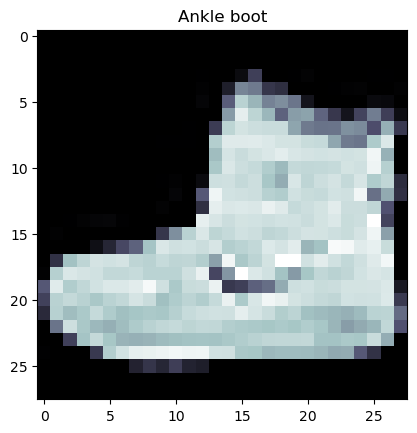

In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure()
plt.imshow(x_train[0], cmap='bone')
plt.grid(False)
plt.title(class_names[y_train[0]])
plt.show()

Clean the data

In [3]:
# Corrects the range of the pixels
x_train = x_train / 255
x_test = x_test / 255

#Flatten x vals
flatten_xtrain = []
flatten_xtest = []
for (x1, x2) in zip(x_train, x_test):
    flatten_xtrain.append(x1.flatten().reshape(-1,1))
    flatten_xtest.append(x2.flatten().reshape(-1,1))

#Onehot encode y vals
ohe_ytrain = []
ohe_ytest = []
for (y1, y2) in zip(y_train, y_test):
    temp_vec1 = np.zeros((10,1))
    temp_vec1[y1] = 1.0
    ohe_ytrain.append(temp_vec1)
    
    temp_vec2 = np.zeros((10,1))
    temp_vec2[y2] = 1.0
    ohe_ytest.append(temp_vec2)

Activation Function, it's derivative, and the cost function

In [4]:
#Activation Function (Sigmoid)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Activation Function's Derivative
def d_sigmoid(z):
    sig_z = sigmoid(z)
    return sig_z * (1 - sig_z)

#Cost Function (MSE)
def mse(actual, cost):
    return 0.5 * sum((actual[i] - cost[i]) ** 2 for i in range(10))[0]

Implementing our Multi-Layer Neuron

In [9]:
class MultiLayerNeuron(object):
    def __init__(self, activation_func, activation_derivative_func, cost_func, layers=[784, 120, 120, 120, 10]):
        self.d_activation = activation_derivative_func
        self.activation = activation_func
        self.cost_func = cost_func
        self.layers = layers
        self.W, self.B = self.init_weights(layers)

    def init_weights(self, layers):
        weights = [[0.0]]
        biases = [[0.0]]
        for i in range(1, len(layers)): #the np.sqrt coefficient speeds up training
            w_temp = np.random.randn(layers[i], layers[i-1]) #* np.sqrt(2/layers[i-1])
            b_temp = np.random.randn(layers[i], 1) #* np.sqrt(2/layers[i-1])

            weights.append(w_temp)
            biases.append(b_temp)
        return weights, biases

    def avg_cost(self, X, y):
        cost = 0.0
        m = 0
        for xi, yi in zip(X, y):
            _, a = self.forward_pass(xi)
            cost += self.cost_func(a[-1], yi)
            m+=1
        return cost/m

    def forward_pass(self, xi):
        Z = [[0.0]]
        A = [xi]
        #0th weight is 0.0
        for i in range(1, len(self.W)):
            z = self.W[i] @ A[i-1] + self.B[i]
            a = self.activation(z)
            Z.append(z)
            A.append(a)
        return Z, A

    def predict_vector(self, xi):
        _, A = self.forward_pass(xi)
        return A[-1]

    def predict(self, xi):
        _, A = self.forward_pass(xi)
        return np.argmax(A[-1])
    
    def train(self, x_train, y_train, alpha=0.09, epochs=3):
        self.errors_ = [self.avg_cost(x_train, y_train)]
        print(f"Starting cost: {self.errors_[0]}")
        
        #Sample size
        sample_size = len(x_train)

        #Num non-input layers
        L = len(self.layers) - 1


        #Perform gradient descent for each epoch
        for e in range(epochs):
            #Loop through the pairs of data
            for (xi, yi) in zip(x_train, y_train):
                #Find pre and post activation vals
                Z, A = self.forward_pass(xi)
                
                #compute output error
                output_err = (A[L] - yi) * self.d_activation(Z[L])
                
                #Add this error to a dictoionary
                deltas = {L: output_err}

                #Loop through the rest of the layers, and compute the errors for each
                for i in range(L-1, 0, -1):
                    deltas[i] = (self.W[i+1].T @ deltas[i+1]) * self.d_activation(Z[i]) 

                #Do gradient descent for each layer
                for i in range(1, L+1):
                    self.W[i] -= alpha*deltas[i] @ A[i-1].T
                    self.B[i] -= alpha*deltas[i]

            #Display the cost over each epoch
            self.errors_.append(self.avg_cost(x_train, y_train))
            print(f"{e+1}-Epoch cost is: {self.errors_[-1]}")

Data Visualization Techniques

In [10]:
def plot_results(i, prediction, actual, img, predict_arr):
    actual, img = actual[i], img[i]
    confidence = np.max(predict_arr)
    for j in range(len(actual)):
        if actual[j] == 1:
            actual = j
            break

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap='bone')

    if actual== prediction:
        color = "green"
    else:
        color = "red"

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[prediction], 100*confidence,
                                         class_names[actual]), color=color)

def plot_value_arr(i, prediction_arr, actual):
    actual = actual[i]
    for j in range(len(actual)):
        if actual[j] == 1:
            actual = j
            break
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])

    thisplot = plt.bar(range(10), prediction_arr, color="#777777")
    plt.ylim([0,1])
    predicted_label = np.argmax(prediction_arr)

    thisplot[predicted_label].set_color('red')
    thisplot[actual].set_color('blue')

Instantiating our class

In [11]:
mln = MultiLayerNeuron(sigmoid, d_sigmoid, mse)
mln.train(flatten_xtrain, ohe_ytrain, alpha=0.005, epochs=20)

Starting cost: 2.467375111385092
1-Epoch cost is: 0.39910349861306993
2-Epoch cost is: 0.3479203685491479
3-Epoch cost is: 0.3058286020119075
4-Epoch cost is: 0.2744094709341285
5-Epoch cost is: 0.2548316647137328
6-Epoch cost is: 0.24081779419117266
7-Epoch cost is: 0.23040586210417513
8-Epoch cost is: 0.22223633921128436
9-Epoch cost is: 0.2155076592914619
10-Epoch cost is: 0.20999718072532914
11-Epoch cost is: 0.205342204219941
12-Epoch cost is: 0.20132319549247088
13-Epoch cost is: 0.19781772736073527
14-Epoch cost is: 0.19470327236849155
15-Epoch cost is: 0.19188961990076264
16-Epoch cost is: 0.1893203833736813
17-Epoch cost is: 0.18695819972582
18-Epoch cost is: 0.1847746579993706
19-Epoch cost is: 0.182744968125732
20-Epoch cost is: 0.18084712087988014


Visualizing the results

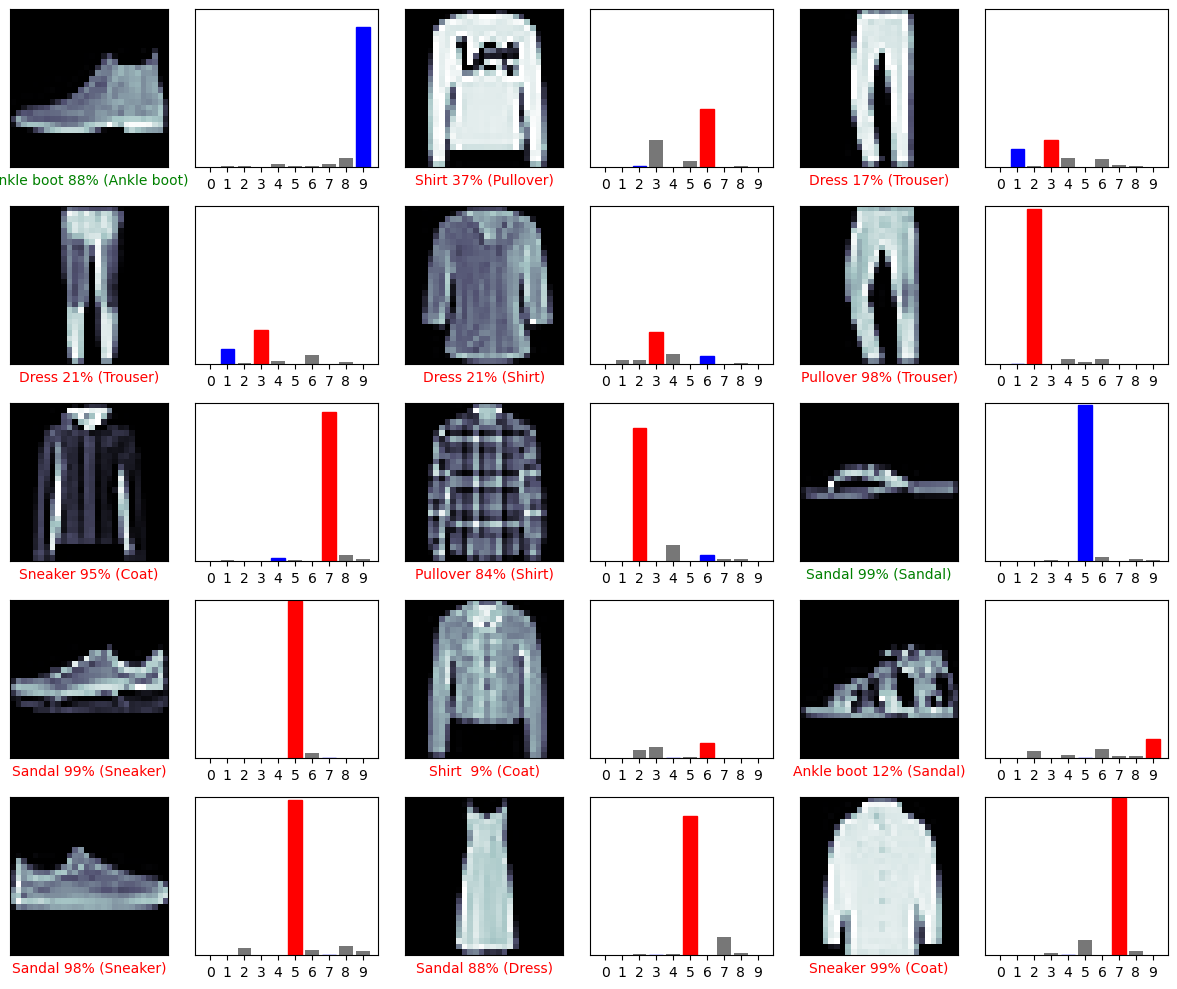

In [12]:
num_rows = 5
num_cols = 3
num_img = num_rows * num_cols
plt.figure(figsize=(4*num_cols, 2*num_rows))

img = x_test
for i in range(num_img):
    predictions = mln.predict(flatten_xtrain[i])
    predict_arr = mln.predict_vector(flatten_xtrain[i]).reshape(-1)

    plt.subplot(num_rows,2*num_cols,2*i+1)
    plot_results(i, predictions, ohe_ytest, img, predict_arr)

    plt.subplot(num_rows,2*num_cols,2*i+2)
    plot_value_arr(i, predict_arr, ohe_ytest)

plt.tight_layout()
plt.show()
